In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from google.colab import files
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.regression.mixed_linear_model import MixedLM

In [ ]:
df1 = pd.read_csv('ins_data_new(5).csv')
df1.head()

,caption,comments1,comments,likes,timestamp,url,collection date,timespan,time,wc,...,saturation,revenue,posts,person,plant,cluster1,cluster2,cluster3,pfr,sfr
0,Design that glows.\n Modern stainless steel ke...,0,0,200,2024-11-04T13:25:55.000Z,https://www.instagram.com/p/DB83jL_SfJw/,16-03-2026,04-11-2024,405,12,...,1,2.220756,9100,1,1,NaN,1,1,2,0
1,Modern materials. Sleek lines. The Quinn Dress...,80,21,281,2026-02-25T19:01:07.000Z,https://www.instagram.com/p/DVMEMghARe4/,16-03-2026,25-02-2026,7,47,...,95,0.000000,4680,1,1,NaN,1,0,9,0
2,Turn heads with the sculptural silhouette of t...,0,21,840,2026-03-03T18:01:55.000Z,https://www.instagram.com/p/DVbaGXegTgi/,16-03-2026,03-03-2026,4,13,...,122,4.704805,4680,0,1,NaN,1,0,0,0
3,Prepare to refresh your home with our most exq...,0,19,2010,2026-03-01T18:00:47.000Z,https://www.instagram.com/p/DVWQaosgXrY/,16-03-2026,01-03-2026,5,22,...,117,3.974343,4680,0,1,NaN,1,1,0,0
4,"Crafted by Aaron Probyn, our Kanto stoneware i...",73,73,2500,2024-09-15T12:30:00.000Z,https://www.instagram.com/p/C_8BbI3Nm-i/,16-03-2026,15-09-2024,434,22,...,77,3.046570,12300,0,0,NaN,1,1,0,0


In [ ]:
df1['pf'] = pd.to_numeric(df1['pf'], errors='coerce')
df1['sfr'] = pd.to_numeric(df1['sfr'], errors='coerce')
s1=df1.describe()
display(s1)

,comments1,comments,likes,time,wc,log(wc),post interval,pf,sf,sf_new,saturation,revenue,posts,person,plant,cluster1,cluster2,cluster3,pfr,sfr
count,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,0.0,542.000000,542.000000,542.000000,542.000000
mean,44.468635,43.130996,2841.105166,164.883764,40.806273,3.465337,0.826568,1.568266,3.878229,4.143911,58.230627,3.257611,8324.538745,0.494465,0.498155,NaN,0.461255,0.477860,3.247232,4.012915
std,61.463557,59.888370,1371.339524,121.586734,36.613399,0.699193,1.105939,1.471211,2.962477,3.577186,49.091942,1.655657,3100.934995,0.500431,0.500458,NaN,0.498957,0.499971,3.063973,3.496740
min,0.000000,0.000000,96.000000,1.000000,3.000000,1.386294,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4680.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2433.750000,58.000000,19.000000,2.995732,0.000000,1.000000,2.000000,1.000000,20.000000,2.261032,4750.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000
50%,37.000000,33.500000,3000.000000,152.500000,26.000000,3.295837,1.000000,1.000000,4.000000,3.000000,52.500000,3.689714,9100.000000,0.000000,0.000000,NaN,0.000000,0.000000,2.000000,3.000000
75%,71.000000,68.000000,3346.750000,237.750000,52.000000,3.970292,1.000000,2.000000,6.000000,6.000000,86.000000,4.651611,10350.000000,1.000000,1.000000,NaN,1.000000,1.000000,5.000000,6.000000
max,353.000000,353.000000,19815.000000,449.000000,310.000000,5.739793,11.000000,10.000000,14.000000,14.000000,255.000000,5.321453,12300.000000,1.000000,1.000000,NaN,1.000000,1.000000,11.000000,13.000000


In [ ]:
display(s1['revenue'])

,revenue
count,542.000000
mean,3.257611
std,1.655657
min,0.000000
25%,2.261032
50%,3.689714
75%,4.651611
max,5.321453


In [ ]:
display(s1['sf_new'])

,sf_new
count,542.000000
mean,4.143911
std,3.577186
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,14.000000


In [ ]:
display(s1['pf'])
#1.469

,pf
count,542.000000
mean,1.568266
std,1.471211
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,10.000000


In [ ]:
col= ['likes', 'comments', 'pf', 'sf_new', 'saturation', 'log(wc)', 'post interval','revenue','time','posts']
df1[col]

,likes,comments,pf,sf_new,saturation,log(wc),post interval,revenue,time,posts
0,200,0,1,0,1,2.564949,0,2.220756,405,9100
1,281,21,1,0,95,3.871201,0,0.000000,7,4680
2,840,21,0,0,122,2.639057,0,4.704805,4,4680
3,2010,19,2,0,117,3.135494,1,3.974343,5,4680
4,2500,73,2,0,77,3.135494,1,3.046570,434,12300
...,...,...,...,...,...,...,...,...,...,...
537,2925,0,0,13,80,3.091042,0,0.000000,23,4750
538,2933,0,2,13,66,2.944439,2,2.335526,322,12300
539,2933,80,1,13,42,2.708050,2,4.791508,371,9100
540,2547,0,9,14,168,2.708050,1,4.371798,15,4680


In [ ]:
col1= ['likes', 'comments']
df1[col1]

,likes,comments
0,200,0
1,281,21
2,840,21
3,2010,19
4,2500,73
...,...,...
537,2925,0
538,2933,0
539,2933,80
540,2547,0


In [ ]:
df1['sf2'] = df1['sf_new'] ** 2
df1['sf2'].head()

,sf2
0,0
1,0
2,0
3,0
4,0


REGRESSION MODEL WITH PRIMARY FEATURES

In [ ]:
# Calculate and display descriptive statistics for the DataFrame
s1=df1.describe()
display(s1)

,comments1,comments,likes,time,wc,log(wc),post interval,pf,sf,sf_new,...,revenue,posts,person,plant,cluster1,cluster2,cluster3,pfr,sfr,sf2
count,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,...,542.000000,542.000000,542.000000,542.000000,0.0,542.000000,542.000000,542.000000,542.000000,542.000000
mean,44.468635,43.130996,2841.105166,164.883764,40.806273,3.465337,0.826568,1.568266,3.878229,4.143911,...,3.257611,8324.538745,0.494465,0.498155,NaN,0.461255,0.477860,3.247232,4.012915,29.944649
std,61.463557,59.888370,1371.339524,121.586734,36.613399,0.699193,1.105939,1.471211,2.962477,3.577186,...,1.655657,3100.934995,0.500431,0.500458,NaN,0.498957,0.499971,3.063973,3.496740,42.609874
min,0.000000,0.000000,96.000000,1.000000,3.000000,1.386294,0.000000,0.000000,0.000000,0.000000,...,0.000000,4680.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2433.750000,58.000000,19.000000,2.995732,0.000000,1.000000,2.000000,1.000000,...,2.261032,4750.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
50%,37.000000,33.500000,3000.000000,152.500000,26.000000,3.295837,1.000000,1.000000,4.000000,3.000000,...,3.689714,9100.000000,0.000000,0.000000,NaN,0.000000,0.000000,2.000000,3.000000,9.000000
75%,71.000000,68.000000,3346.750000,237.750000,52.000000,3.970292,1.000000,2.000000,6.000000,6.000000,...,4.651611,10350.000000,1.000000,1.000000,NaN,1.000000,1.000000,5.000000,6.000000,36.000000
max,353.000000,353.000000,19815.000000,449.000000,310.000000,5.739793,11.000000,10.000000,14.000000,14.000000,...,5.321453,12300.000000,1.000000,1.000000,NaN,1.000000,1.000000,11.000000,13.000000,196.000000


In [ ]:
mean_values = s1.loc['mean']
display(mean_values)

,mean
comments1,44.468635
comments,43.130996
likes,2841.105166
time,164.883764
wc,40.806273
log(wc),3.465337
post interval,0.826568
pf,1.568266
sf,3.878229
sf_new,4.143911


In [ ]:
r1 = s1
smean_r1 = r1.loc['mean'].sum()
print(f"Sum of the mean of all columns in r1: {smean_r1}")

Sum of the mean of all columns in r1: 11573.440660831195


In [ ]:
r2=s1[['revenue']]
display(r2)

,revenue
count,542.000000
mean,3.257611
std,1.655657
min,0.000000
25%,2.261032
50%,3.689714
75%,4.651611
max,5.321453


In [ ]:
r3=s1[['posts']]
display(r3)

,posts
count,542.000000
mean,8324.538745
std,3100.934995
min,4680.000000
25%,4750.000000
50%,9100.000000
75%,10350.000000
max,12300.000000


In [ ]:
#REGRESSION MODEL WITH PRIMARY FEATURES

features = ['time','saturation','log(wc)','pf','post interval','revenue','posts']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels

X = sm.add_constant(X)
# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [ ]:
# Fit the Logistic Regression model with scaled features
logit_model_scaled = sm.Logit(y_binary, X_scaled)
logit_result_scaled = logit_model_scaled.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---")
print(logit_result_scaled.summary())
print("\nLogistic Regression (Zero vs. Non-Zero Likes) with Scaled Features:")
print(f"  AIC: {logit_result_scaled.aic}")
print(f"  BIC: {logit_result_scaled.bic}")


--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      542
Method:                           MLE   Df Model:                           -1
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:11   Log-Likelihood:                -375.69
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

In [ ]:
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

# Separate the constant column from features for scaling
X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model with correctly scaled features
nbreg_model_scaled = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result_scaled = nbreg_model_scaled.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---")
print(nbreg_result_scaled.summary())
print(f"  AIC: {nbreg_result_scaled.aic}")
print(f"  BIC: {nbreg_result_scaled.bic}")

Optimization terminated successfully.
         Current function value: 8.576449
         Iterations: 8
         Function evaluations: 15
         Gradient evaluations: 15

--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      534
Method:                           MLE   Df Model:                            7
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.001625
Time:                        16:26:11   Log-Likelihood:                -4648.4
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                   0.03431
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

In [ ]:
variables = ['time', 'log(wc)', 'pf', 'saturation', 'post interval', 'revenue', 'posts']

# Get coefficients from logit_result_secondary.params
coefficients = {var: nbreg_result_scaled.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=nbreg_result_scaled.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates(priimary features): {b}")

Coefficients: {'time': np.float64(0.031778735613490774), 'log(wc)': np.float64(-0.04271938460982804), 'pf': np.float64(-0.005412793090607136), 'saturation': np.float64(0.019473260907332604), 'post interval': np.float64(-0.04210160360535517), 'revenue': np.float64(0.025899437665731103), 'posts': np.float64(0.04262742021033154)}
Mean values: {'time': np.float64(164.88376383763838), 'log(wc)': np.float64(3.465337164175277), 'pf': np.float64(1.5682656826568266), 'saturation': np.float64(58.230627306273064), 'post interval': np.float64(0.8265682656826568), 'revenue': np.float64(3.2576114899022146), 'posts': np.float64(8324.538745387454)}
Sum of (coefficient * mean) for selected variables: 361.1203935805803
Linear predictor (log-odds) at the mean of covariates(priimary features): 369.0688907301088


In [ ]:
#REGRESSION MODEL WITH SECONDARY FEATURES

features = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


In [ ]:
# Fit the Logistic Regression model with scaled features
logit_model_scaled = sm.Logit(y_binary, X_scaled)
logit_result_scaled = logit_model_scaled.fit_regularized(method='l1', alpha=0.1, disp=False)
print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---")
print(logit_result_scaled.summary())
print("\nLogistic Regression (Zero vs. Non-Zero Likes) with Scaled Features:")
print(f"  AIC: {logit_result_scaled.aic}")
print(f"  BIC: {logit_result_scaled.bic}")
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

# Separate the constant column from features for scaling
X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model with correctly scaled features
nbreg_model_scaled = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result_scaled = nbreg_model_scaled.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---")
print(nbreg_result_scaled.summary())
print(f"  AIC: {nbreg_result_scaled.aic}")
print(f"  BIC: {nbreg_result_scaled.bic}")


--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      542
Method:                           MLE   Df Model:                           -1
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:11   Log-Likelihood:                -375.69
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

Optimization terminated successfully.
         Current function value: 8.566809
         Iterations: 14
         Function evaluations: 21
         Gradient evaluations: 21

--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      533
Method:                           MLE   Df Model:                            8
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.002747
Time:                        16:26:12   Log-Likelihood:                -4643.2
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                  0.001237
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

In [ ]:
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

# Separate the constant column from features for scaling
X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model with correctly scaled features
nbreg_model_scaled = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result_scaled = nbreg_model_scaled.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---")
print(nbreg_result_scaled.summary())
print(f"  AIC: {nbreg_result_scaled.aic}")
print(f"  BIC: {nbreg_result_scaled.bic}")

Optimization terminated successfully.
         Current function value: 8.566809
         Iterations: 14
         Function evaluations: 21
         Gradient evaluations: 21

--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      533
Method:                           MLE   Df Model:                            8
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.002747
Time:                        16:26:12   Log-Likelihood:                -4643.2
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                  0.001237
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

In [ ]:
variables = ['time', 'log(wc)', 'saturation', 'post interval', 'revenue', 'posts','sf_new']

# Get coefficients from logit_result_secondary.params
coefficients = {var: logit_result.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=nbreg_result_scaled.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates(secondary features): {b}")

Coefficients: {'time': np.float64(0.0), 'log(wc)': np.float64(0.0), 'saturation': np.float64(0.0), 'post interval': np.float64(0.0), 'revenue': np.float64(0.0), 'posts': np.float64(0.0034235231760641263), 'sf_new': np.float64(0.0)}
Mean values: {'time': np.float64(164.88376383763838), 'log(wc)': np.float64(3.465337164175277), 'saturation': np.float64(58.230627306273064), 'post interval': np.float64(0.8265682656826568), 'revenue': np.float64(3.2576114899022146), 'posts': np.float64(8324.538745387454), 'sf_new': np.float64(4.143911439114391)}
Sum of (coefficient * mean) for selected variables: 28.499251324877733
Linear predictor (log-odds) at the mean of covariates(secondary features): 36.44541796127734


REGRESSION MODEL WITH FEATURES

In [ ]:
features = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new','sf2']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


In [ ]:
# Fit the Logistic Regression model with scaled features
# Re-scale X based on the features defined in the preceding cell (4NcrKC0rgWns)
# X from 4NcrKC0rgWns has 10 columns (9 features + const)
scaler = StandardScaler()
# Temporarily drop 'const' for scaling, then add it back
X_features_only = X.drop(columns='const')
X_scaled_features = scaler.fit_transform(X_features_only)
X_scaled = pd.DataFrame(X_scaled_features, columns=X_features_only.columns, index=X_features_only.index)
X_scaled = sm.add_constant(X_scaled, has_constant='add') # Add constant back

logit_model_scaled = sm.Logit(y_binary, X_scaled)
logit_result_scaled = logit_model_scaled.fit_regularized(method='l1', alpha=0.1, disp=False)
print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---")
print(logit_result_scaled.summary())
print("\nLogistic Regression (Zero vs. Non-Zero Likes) with Scaled Features:")
print(f"  AIC: {logit_result_scaled.aic}")
print(f"  BIC: {logit_result_scaled.bic}")

df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
# X_positive should also be based on the current X (with 10 columns)
X_positive = X.loc[df_positive_likes.index]

# Separate the constant column from features for scaling
X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model with correctly scaled features
nbreg_model = sm.NegativeBinomial(y_positive, X_positive)
nbreg_result = nbreg_model.fit()

# Fit the Negative Binomial Regression model with correctly scaled features
nbreg_model_scaled = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result_scaled = nbreg_model_scaled.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---")
print(nbreg_result_scaled.summary())
print(f"  AIC: {nbreg_result_scaled.aic}")
print(f"  BIC: {nbreg_result_scaled.bic}")


--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:12   Log-Likelihood:               -0.10001
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.5976      3.163      2.719      0.007       2.399      14.796
time                   0        nan        nan

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

In [ ]:
variables = ['time', 'log(wc)', 'saturation', 'post interval', 'revenue', 'posts','sf_new','sf2']

# Get coefficients from logit_result_secondary.params
coefficients = {var: nbreg_result_scaled.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=nbreg_result_scaled.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates(primary and secondary features): {b}")

Coefficients: {'time': np.float64(0.03179668506142504), 'log(wc)': np.float64(-0.03704004677401922), 'saturation': np.float64(0.0225917158549272), 'post interval': np.float64(-0.04469176027678173), 'revenue': np.float64(0.020256398209236973), 'posts': np.float64(0.04121017348569957), 'sf_new': np.float64(0.26085502421814977), 'sf2': np.float64(-0.20492119191077182)}
Mean values: {'time': np.float64(164.88376383763838), 'log(wc)': np.float64(3.465337164175277), 'saturation': np.float64(58.230627306273064), 'post interval': np.float64(0.8265682656826568), 'revenue': np.float64(3.2576114899022146), 'posts': np.float64(8324.538745387454), 'sf_new': np.float64(4.143911439114391), 'sf2': np.float64(29.944649446494466)}
Sum of (coefficient * mean) for selected variables: 344.45933007949156
Linear predictor (log-odds) at the mean of covariates(primary and secondary features): 352.4033505701496


In [ ]:
for j in range(0,15):
  gj=b+nbreg_result_scaled.params['sf_new']*j+nbreg_result_scaled.params['sf2']*j**2
  print(gj)

352.4033505701496
352.45928440245694
352.10537585094283
351.3416249156071
350.16803159644985
348.5845958934711
346.5913178066707
344.1881973360488
341.37523448160545
338.1524292433404
334.5197816212539
330.47729161534585
326.02495922561627
321.16278445206507
315.8907672946924


q = np.array([3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2])

In [ ]:
k=1
scale_factor = 5000
i=3
j=7
xk=scale_factor*(b+(nbreg_result_scaled.params['pf']*i)+(nbreg_result_scaled.params['sf_new']*j)+(nbreg_result_scaled.params['sf2']*j**2))

print(xk)

NameError: name 'b' is not defined

In [ ]:
import numpy as np
import pandas as pd


K = 14  # 14-day planning horizon
B = 10000  # Total budget
a = 20  # Unit development cost per feature
C_f = 0  # Fixed analytics cost
e_values = [20, 30, 40, 50, 60, 70, 80, 90]  # Unit analytics effort costs

# Mandatory primary features q_k (Fixed sample generated between 1 and 6)
np.random.seed(77)
q = np.array([3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2])

w = np.array([10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10])

# Regression estimates for Instagram Likes (Case 1)
b_lm = 7.9440
beta_lm = -0.0144
zeta_lm = 0.2609
eta_lm = -0.2049


# Pre-calculate lookup table g_j for j = 0 to 8
# g_j = scale_factor * (b_lm + zeta_lm*j + eta_lm*j^2)
g_j = np.array([
    scale_factor * (b_lm + zeta_lm * j + eta_lm * (j ** 2))
    for j in range(9)
])

# Optimal/Maximum secondary features for Case 1
f_max_star = 8  # According to Lemma 2

# ==========================================
# 2. ALGORITHM 1: FAAS(Case 1) IMPLEMENTATION
# ==========================================
def run_faas_case1(e_cost):

    best_overall_engagement = -1
    best_U = 0
    best_f_alloc = np.zeros(K, dtype=int)
    best_leftover_budget = 0

    # Primary features are fixed to mandatory lower bounds s_k = q_k (Lemma 1)
    s = q.copy()
    cost_primary = a * np.sum(s)

    # Sort day indices in non-increasing order of engagement weights w_k
    sorted_day_indices = np.argsort(-w)

    # Outer loop: Try all possible analytics upper bounds U from f_max_star down to 0
    for U in range(f_max_star, -1, -1):
        # Remaining budget available for secondary features
        B_prime = B - cost_primary - (e_cost * U) - C_f

        if B_prime < 0:
            continue  # Infeasible budget for this U

        f_current = np.zeros(K, dtype=int)
        temp_budget = B_prime

        # Greedy allocation based on day weights w_k
        for idx in sorted_day_indices:
            # Allocate maximum possible secondary features (r <= U) within budget
            max_affordable_r = int(temp_budget // a)
            r = min(U, max_affordable_r)

            f_current[idx] = r
            temp_budget -= r * a

        # Calculate daily engagement x_k and total weighted objective Pi_s
        x_k = (beta_lm * s * scale_factor) + g_j[f_current]
        total_engagement = np.sum(w * x_k)

        # Track the solution that yields maximum engagement
        if total_engagement > best_overall_engagement:
            best_overall_engagement = total_engagement
            best_U = U
            best_f_alloc = f_current.copy()
            best_leftover_budget = temp_budget

    return best_U, best_overall_engagement, best_f_alloc, best_leftover_budget

results = []

for e in e_values:
    opt_U, total_eng, f_alloc, leftover_b = run_faas_case1(e)

    res_dict = {
        "Unit Cost (e)": e,
        "Optimal U": opt_U,
        "Total Engagement": round(total_eng),
        "Leftover Budget": int(leftover_b),
    }
    # Add secondary features assigned for each day
    for day in range(K):
        res_dict[f"Day {day+1} (s_k, f_k)"] = f"({q[day]}, {f_alloc[day]})"

    results.append(res_dict)

# Display as DataFrame formatted similarly to Table EC.37
df_results = pd.DataFrame(results)
print("=== REPRODUCED TABLE EC.37 (FAAS Case 1 Results for Instagram) ===")
print(df_results[["Unit Cost (e)", "Optimal U", "Total Engagement", "Leftover Budget"]].to_string(index=False))

print("\nDetailed Feature Allocation Schedule:")
print(df_results.drop(columns=["Total Engagement", "Leftover Budget"]).to_string(index=False))

=== REPRODUCED TABLE EC.37 (FAAS Case 1 Results for Instagram) ===
 Unit Cost (e)  Optimal U  Total Engagement  Leftover Budget
            20          1           7326736             9000
            30          1           7326736             8990
            40          1           7326736             8980
            50          1           7326736             8970
            60          1           7326736             8960
            70          1           7326736             8950
            80          1           7326736             8940
            90          1           7326736             8930

Detailed Feature Allocation Schedule:
 Unit Cost (e)  Optimal U Day 1 (s_k, f_k) Day 2 (s_k, f_k) Day 3 (s_k, f_k) Day 4 (s_k, f_k) Day 5 (s_k, f_k) Day 6 (s_k, f_k) Day 7 (s_k, f_k) Day 8 (s_k, f_k) Day 9 (s_k, f_k) Day 10 (s_k, f_k) Day 11 (s_k, f_k) Day 12 (s_k, f_k) Day 13 (s_k, f_k) Day 14 (s_k, f_k)
            20          1           (3, 1)           (4, 1)           (2, 1)

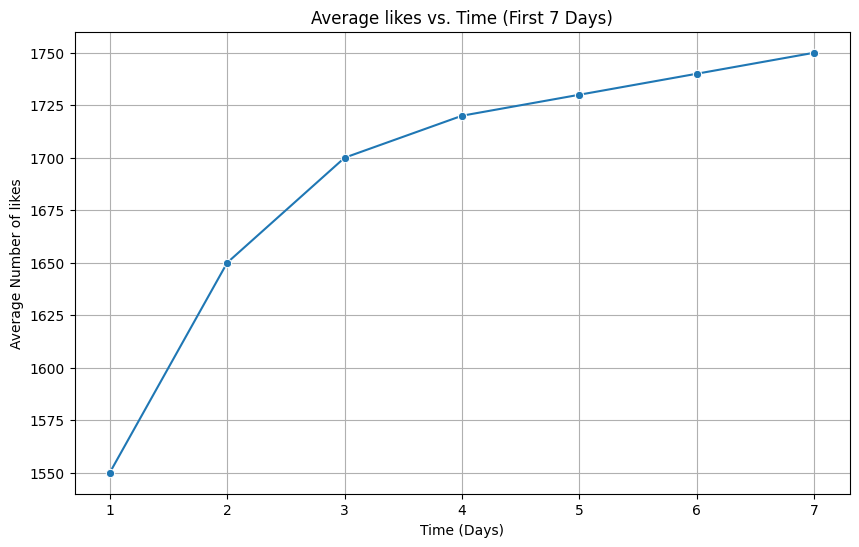

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'time' and calculate the average comments
avg_likes_per_time = df1.groupby('time')['likes'].mean().reset_index()

# Filter for the first 7 days (assuming 'time' represents days)
avg_likes_7_days = avg_likes_per_time[avg_likes_per_time['time'] <= 7]

plt.figure(figsize=(10, 6))
sns.lineplot(x='time', y='likes', data=avg_likes_7_days, marker='o')
plt.title('Average likes vs. Time (First 7 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Average Number of likes')
plt.grid(True)
plt.xticks(avg_likes_7_days['time'])
plt.show()

In [ ]:
csf=logit_result.params['sf_new']
display(csf)
csf2=logit_result.params['sf2']
display(csf2)
c_const=logit_result.params['const']
display(c_const)

np.float64(0.0)

np.float64(0.0)

np.float64(0.0)

/tmp/ipykernel_3093/2483917418.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_original['sf2'] = X_original['sf_new'] ** 2


0     2400.487489
1     2425.802012
2     2450.893623
3     2475.749937
4     2500.358581
         ...     
95    2664.219250
96    2641.680712
97    2618.809413
98    2595.617336
99    2572.116550
Length: 100, dtype: float64


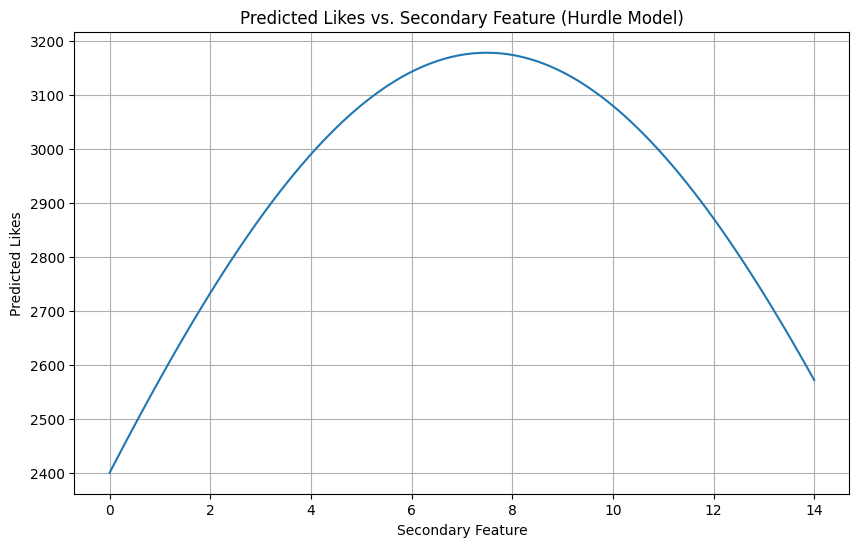

In [ ]:
#GRAPH PLOT

import matplotlib.pyplot as plt
import seaborn as sns

# --- Prediction Phase for Hurdle Model ---

# 1. Create a range of 'secondary feature' values for prediction
secondary_feature_range = np.linspace(df1['sf_new'].min(), df1['sf_new'].max(), 100)

# 2. Create a DataFrame for prediction, holding other variables constant
# We'll use the mean of other features from the original DataFrame X

# Re-extract features to ensure consistency with the last model run
features_for_prediction = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new','sf2']
X_original = df1[features_for_prediction]
X_original['sf2'] = X_original['sf_new'] ** 2

# Add constant for statsmodels
X_original = sm.add_constant(X_original, has_constant='add')

# Ensure all columns are numeric and handle NaNs for mean calculation
for col in X_original.columns:
    X_original[col] = pd.to_numeric(X_original[col], errors='coerce')
X_original = X_original.fillna(X_original.mean())


# Create a template for new predictions with mean values for other features
pred_df = pd.DataFrame(columns=X_original.columns)
mean_values = X_original.mean().to_dict()

# Populate pred_df with mean values for all columns
for col in pred_df.columns:
    pred_df[col] = [mean_values[col]] * len(secondary_feature_range)

# Replace 'secondary feature' and 'sf2' with the desired range
pred_df['sf_new'] = secondary_feature_range
pred_df['sf2'] = secondary_feature_range ** 2 # Calculate sf2 based on the new range


# 3. Predict the probability of non-zero likes (from logit_result)
prob_non_zero = logit_result.predict(pred_df)

# 4. Predict the expected value of positive likes (from nbreg_result)
# Note: nbreg_result uses the same X as logit_result, which includes 'const'
expected_positive_likes = nbreg_result.predict(pred_df)
print(expected_positive_likes)
# 5. Combine predictions: P(likes > 0) * E(likes | likes > 0)
predicted_likes_hurdle = prob_non_zero * expected_positive_likes
# --- Visualization ---

plt.figure(figsize=(10, 6))
sns.lineplot(x=secondary_feature_range, y=predicted_likes_hurdle)
plt.title('Predicted Likes vs. Secondary Feature (Hurdle Model)')
plt.xlabel('Secondary Feature')
plt.ylabel('Predicted Likes')
plt.grid(True)
plt.show()

In [ ]:
col2= ['likes','pf', 'sf']
df1[col2]

,likes,pf,sf
0,200,1,0
1,281,1,6
2,840,0,0
3,2010,2,0
4,2500,2,0
...,...,...,...
537,2925,0,3
538,2933,2,4
539,2933,1,0
540,2547,9,7


REGRESSION MODEL WITHOUT FEATURES


In [ ]:
#REGRESSION MODEL WITHOUT FEATURES

features = ['time','saturation','log(wc)','post interval','revenue','posts']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

In [ ]:
# Fit the Logistic Regression model with scaled features
logit_model_scaled = sm.Logit(y_binary, X_scaled)
logit_result_scaled = logit_model_scaled.fit_regularized(method='l1', alpha=0.1, disp=False)
print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---")
print(logit_result_scaled.summary())
print("\nLogistic Regression (Zero vs. Non-Zero Likes) with Scaled Features:")
print(f"  AIC: {logit_result_scaled.aic}")
print(f"  BIC: {logit_result_scaled.bic}")
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

# Separate the constant column from features for scaling
X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model with correctly scaled features
nbreg_model_scaled = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result_scaled = nbreg_model_scaled.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) with Scaled Features ---")
print(nbreg_result_scaled.summary())
print(f"  AIC: {nbreg_result_scaled.aic}")
print(f"  BIC: {nbreg_result_scaled.bic}")


--- Logistic Regression (Zero vs. Non-Zero Likes) with Scaled Features ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:13   Log-Likelihood:               -0.10001
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.5976      3.163      2.719      0.007       2.399      14.796
time                   0        nan        nan

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

In [ ]:
#Quantile Regression analysis complete
import statsmodels.formula.api as smf

# Define the formula for the quantile regression model
# Using the same predictors as the ZINB model for consistency
formula = 'likes ~ pf + sf_new + sf2 + time + Q("log(wc)") + saturation + Q("post interval") + revenue + Q("posts")'

# List of quantiles to analyze
quantiles = [0.50, 0.70, 0.90]

print("Performing Quantile Regression for different quantiles...")

# Loop through each quantile and fit the model
for q in quantiles:
    print(f"\n--- Quantile Regression for {int(q*100)}th Percentile ---")
    # Fit the Quantile Regression model
    mod = smf.quantreg(formula, data=df1)
    res = mod.fit(q=q)

    # Print the summary of the results
    print(res.summary())

print("Quantile Regression analysis complete.")

Performing Quantile Regression for different quantiles...

--- Quantile Regression for 50th Percentile ---
                         QuantReg Regression Results                          
Dep. Variable:                  likes   Pseudo R-squared:               0.2158
Model:                       QuantReg   Bandwidth:                       171.0
Method:                 Least Squares   Sparsity:                        537.8
Date:                Sat, 01 Aug 2026   No. Observations:                  542
Time:                        16:26:13   Df Residuals:                      532
                                        Df Model:                            9
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2378.2721     79.748     29.822      0.000    2221.612    2534.932
pf                     1.3120      8.403      0.156      0.876     -15.196     

In [ ]:
#Fitting Mixed-Effects Model for 'likes'...
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

# Define the formula for the mixed-effects model
# 'comments' is the dependent variable
# 'pf + sf + sf2 + time + logwc + saturation + post_interval + revenue' are fixed effects
# 'page active' is specified as the grouping variable for random effects
formula = 'likes ~ pf + sf_new + sf2 + time + Q("log(wc)") + saturation + Q("post interval") + revenue'

# Identify all columns used in the model, including the dependent variable and groups
model_columns = ['likes', 'pf', 'sf_new', 'sf2', 'time', 'log(wc)', 'saturation', 'post interval', 'revenue', 'posts']

# Create a new DataFrame with only the relevant columns and drop rows with NaN values
# This ensures that 'data' and 'groups' have perfectly aligned indices and sizes
model_df = df1[model_columns].dropna()

# Fit the Mixed-Effects Model
# Pass the cleaned model_df and its 'page active' column for groups
print("Fitting Mixed-Effects Model for 'likes'...")
mixed_model = MixedLM.from_formula(formula, data=model_df, groups=model_df["posts"])

# Try to fit the model. It might take a moment.
# Using a robust covariance estimator can help with issues like heteroscedasticity
try:
    mixed_results = mixed_model.fit(maxiter=1000)
    print(mixed_results.summary())
except Exception as e:
    print(f"An error occurred during mixed-effects model fitting: {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Ensure the grouping variable has sufficient variation (more than one group).")
    print("3. Consider simplifying the random effects structure if convergence is an issue.")
    print("4. Try different optimization algorithms or increasing maxiter.")

Fitting Mixed-Effects Model for 'likes'...
               Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    likes       
No. Observations:    542        Method:                REML        
No. Groups:          5          Scale:                 1787908.5000
Min. group size:     78         Log-Likelihood:        -4635.0314  
Max. group size:     129        Converged:             Yes         
Mean group size:     108.4                                         
-------------------------------------------------------------------
                    Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
-------------------------------------------------------------------
Intercept          2721.815  379.102  7.180 0.000 1978.788 3464.842
pf                  -33.541   42.882 -0.782 0.434 -117.588   50.507
sf_new              211.482   50.466  4.191 0.000  112.572  310.393
sf2                 -14.215    4.242 -3.351 0.001  -22.528   -5.901
time                

In [ ]:
# Define dependent and independent variables for the GNB model
Y_comments_gnb = df1['likes']
X_var_gnb = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new','sf2']
X_comments_gnb = df1[X_var_gnb]

# Combine and drop NaNs to ensure consistent data for the model
data_for_gnb_model = pd.concat([Y_comments_gnb, X_comments_gnb], axis=1)
data_for_gnb_model = data_for_gnb_model.dropna(subset=['likes'] + X_var_gnb)
data_for_gnb_model['likes'] = data_for_gnb_model['likes'].astype(float).astype(int)

Y_clear_gnb = data_for_gnb_model['likes']
X_clear_gnb = data_for_gnb_model[X_var_gnb]

# Scale the independent variables
scaler_gnb = StandardScaler()
X_scaled_gnb = scaler_gnb.fit_transform(X_clear_gnb)
X_clear_gnb = pd.DataFrame(X_scaled_gnb, columns=X_var_gnb, index=X_clear_gnb.index)

# Add a constant (intercept) to the independent variables
X_clear_gnb = sm.add_constant(X_clear_gnb, prepend=False)

try:
    print("Fitting Generalized Negative Binomial Regression model for 'likes'...")
    gnb_model = NegativeBinomial(endog=Y_clear_gnb, exog=X_clear_gnb)

    # Attempt to get default start_params if available or initialize with zeros
    try:
        # Try a quick fit for initial params, then perturb to avoid local optima
        start_params_gnb = gnb_model.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params_gnb = np.zeros(len(X_clear_gnb.columns) + 1) # exog_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    gnb_results = gnb_model.fit(maxiter=1000, disp=False, start_params=start_params_gnb)
    print(gnb_results.summary())
except Exception as e:
    print(f"An error occurred during GNB model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables if not already done.")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers).")

Fitting Generalized Negative Binomial Regression model for 'likes'...
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      532
Method:                           MLE   Df Model:                            9
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.003798
Time:                        16:26:13   Log-Likelihood:                -4638.3
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                 5.128e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.0318      0.027      1.169      0.242      -0.022       0.085
saturation        0.0226      0.023      0.978      

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


In [ ]:
display(s1['pf'])

,pf
count,542.000000
mean,1.568266
std,1.471211
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,10.000000


### Robustness Check for Negative Binomial Model with Scaled Features

This section performs a robustness check on the Negative Binomial regression model. The model is re-fitted on a randomly selected 90% subset of the data, and its coefficients and p-values are compared against the original model to assess the stability of the estimates.

In [ ]:
# Re-define features and prepare data consistently with the last scaled NB model (Gl_fF9Iqd1xu)
features_scaled_nb = ['time','log(wc)','saturation','post interval','revenue','posts','sf_new']

df_positive_likes_rc = df1[df1['likes'] > 0]
y_positive_rc = df_positive_likes_rc['likes']
X_positive_rc = df_positive_likes_rc[features_scaled_nb]

# Ensure all columns in X_positive_rc are numeric
for col in X_positive_rc.columns:
    X_positive_rc[col] = pd.to_numeric(X_positive_rc[col], errors='coerce')

# Handle potential NaN values (e.g., fill with mean)
X_positive_rc = X_positive_rc.fillna(X_positive_rc.mean())

# Scale the features (excluding the constant for now, add it back after scaling)
scaler_rc = StandardScaler()
X_positive_scaled_rc_features = scaler_rc.fit_transform(X_positive_rc)
X_positive_scaled_rc = pd.DataFrame(X_positive_scaled_rc_features, columns=X_positive_rc.columns, index=X_positive_rc.index)

# Add the constant column back to the scaled features
X_positive_scaled_rc = sm.add_constant(X_positive_scaled_rc, has_constant='add')


# --- Original Negative Binomial Model with Scaled Features (for robustness check) ---
original_nbreg_model_scaled_robustness = sm.NegativeBinomial(y_positive_rc, X_positive_scaled_rc)
original_nbreg_result_scaled_robustness = original_nbreg_model_scaled_robustness.fit(disp=False, maxiter=1000)

print("\n--- Original Negative Binomial Regression Results (Scaled Features) ---")
print(original_nbreg_result_scaled_robustness.summary())

# --- Robustness Check (90% Sampled Data) with Scaled Features ---
# Combine X and y for consistent sampling
data_for_sampling = pd.concat([y_positive_rc, X_positive_scaled_rc], axis=1)
sampled_data_rc = data_for_sampling.sample(frac=0.9, random_state=42)

y_positive_sampled_rc = sampled_data_rc['likes']
X_positive_scaled_sampled_rc = sampled_data_rc.drop('likes', axis=1)

# Fit the Negative Binomial Regression model on the sampled data
nbreg_model_sampled_scaled = sm.NegativeBinomial(y_positive_sampled_rc, X_positive_scaled_sampled_rc)
nbreg_result_sampled_scaled = nbreg_model_sampled_scaled.fit(disp=False, maxiter=1000)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results (Scaled Features) ---")
print(nbreg_result_sampled_scaled.summary())

# --- Create DataFrames for comparison ---
original_scaled_nb_coef_pval = pd.DataFrame({
    'Original_Scaled_Coef': original_nbreg_result_scaled_robustness.params,
    'Original_Scaled_P_Value': original_nbreg_result_scaled_robustness.pvalues
})

sampled_scaled_nb_coef_pval = pd.DataFrame({
    'Sampled_Scaled_Coef': nbreg_result_sampled_scaled.params,
    'Sampled_Scaled_P_Value': nbreg_result_sampled_scaled.pvalues
})

# Merge for side-by-side comparison
comparison_scaled_nb_df = pd.merge(
    original_scaled_nb_coef_pval, sampled_scaled_nb_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Scaled Negative Binomial Regression ---")
display(comparison_scaled_nb_df.round(4))


--- Original Negative Binomial Regression Results (Scaled Features) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      534
Method:                           MLE   Df Model:                            7
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.002729
Time:                        16:26:14   Log-Likelihood:                -4643.3
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                 0.0006418
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9462      0.021    377.825      0.000       7.905       7.987
time              0.0318      0.027      1.165   

/tmp/ipykernel_3093/2017691742.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_positive_rc[col] = pd.to_numeric(X_positive_rc[col], errors='coerce')


                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  488
Model:               NegativeBinomial   Df Residuals:                      480
Method:                           MLE   Df Model:                            7
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.003015
Time:                        16:26:14   Log-Likelihood:                -4170.1
converged:                       True   LL-Null:                       -4182.7
Covariance Type:            nonrobust   LLR p-value:                 0.0006929
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9441      0.022    367.025      0.000       7.902       7.987
time              0.0330      0.028      1.177      0.239      -0.022       0.088
log(wc)          -0.0333      0.023     

,Original_Scaled_Coef,Original_Scaled_P_Value,Sampled_Scaled_Coef,Sampled_Scaled_P_Value
alpha,0.2394,0.0000,0.2278,0.0000
const,7.9462,0.0000,7.9441,0.0000
log(wc),-0.0344,0.1248,-0.0333,0.1437
post interval,-0.0417,0.0680,-0.0381,0.1126
posts,0.0446,0.0659,0.0625,0.0123
revenue,0.0248,0.2438,0.0135,0.5430
saturation,0.0152,0.4962,0.0185,0.4149
sf_new,0.0703,0.0014,0.0650,0.0040
time,0.0318,0.2439,0.0330,0.2393


### Robustness Check for Hurdle Model (Logistic Regression Part) with scaled features.

In [ ]:
# --- Robustness Check for Hurdle Model (Logistic Regression Part) with Scaled Features ---
print("\n### Robustness Check for Hurdle Model (Logistic Regression Part) with Scaled Features")

# The original Logistic Regression model used y_binary and X_scaled from previous cells (jNDiPAN3X-93, U3KIyDhFZ_Zp)
# These variables are expected to be available in the global scope from previous executions.

# Re-fitting the original model to get its results consistently for comparison
# Using the same X_scaled and y_binary as used in nm0kzndRZa4i
logit_model_orig_rc = sm.Logit(y_binary, X_scaled)
logit_result_orig_rc = logit_model_orig_rc.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Original Logistic Regression Results (Scaled Features) ---")
print(logit_result_orig_rc.summary())

# --- Robustness Check (90% Sampled Data) for Logistic Regression with Scaled Features ---
# Combine y_binary and X_scaled for consistent sampling
# Ensure 'const' column is treated carefully during sampling as it's part of X_scaled
data_for_sampling_logit = pd.concat([y_binary, X_scaled], axis=1)
sampled_data_logit_rc = data_for_sampling_logit.sample(frac=0.9, random_state=42)

y_binary_sampled_rc = sampled_data_logit_rc['has_likes']
X_scaled_sampled_rc_logit = sampled_data_logit_rc.drop('has_likes', axis=1)

# Fit the Logistic Regression model on the sampled scaled data
logit_model_sampled_rc = sm.Logit(y_binary_sampled_rc, X_scaled_sampled_rc_logit)
logit_result_sampled_rc = logit_model_sampled_rc.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Robustness Check (90% Sampled Data) Logistic Regression Results (Scaled Features) ---")
print(logit_result_sampled_rc.summary())

# --- Create DataFrames for comparison ---
original_scaled_logit_coef_pval = pd.DataFrame({
    'Original_Scaled_Coef': logit_result_orig_rc.params,
    'Original_Scaled_P_Value': logit_result_orig_rc.pvalues
})

sampled_scaled_logit_coef_pval = pd.DataFrame({
    'Sampled_Scaled_Coef': logit_result_sampled_rc.params,
    'Sampled_Scaled_P_Value': logit_result_sampled_rc.pvalues
})

# Merge for side-by-side comparison
comparison_scaled_logit_df = pd.merge(
    original_scaled_logit_coef_pval, sampled_scaled_logit_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Scaled Logistic Regression ---")
display(comparison_scaled_logit_df.round(4))



### Robustness Check for Hurdle Model (Logistic Regression Part) with Scaled Features

--- Original Logistic Regression Results (Scaled Features) ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:14   Log-Likelihood:               -0.10001
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.5976      3.163      2.719      0

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa


--- Robustness Check (90% Sampled Data) Logistic Regression Results (Scaled Features) ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  488
Model:                          Logit   Df Residuals:                      487
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:14   Log-Likelihood:               -0.10001
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.4927      3.163      2.685      0.007       2.294      14.691
time                   0       

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:4469: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.llf/self.llnull


,Original_Scaled_Coef,Original_Scaled_P_Value,Sampled_Scaled_Coef,Sampled_Scaled_P_Value
const,8.5976,0.0066,8.4927,0.0072
log(wc),0.0000,NaN,0.0000,NaN
pf,0.0000,NaN,0.0000,NaN
post interval,0.0000,NaN,0.0000,NaN
posts,0.0000,NaN,0.0000,NaN
revenue,0.0000,NaN,0.0000,NaN
saturation,0.0000,NaN,0.0000,NaN
sf2,0.0000,NaN,0.0000,NaN
sf_new,0.0000,NaN,0.0000,NaN
time,0.0000,NaN,0.0000,NaN


### Robustness Check for Hurdle Model (Negative Binomial Regression Part)

This section performs a robustness check on the Negative Binomial Regression component of the Hurdle model. The model is re-fitted on a randomly selected 90% subset of the data (where likes > 0), and its coefficients and p-values are compared against the original model.

In [ ]:
X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Original Negative Binomial model (from cell GsTbZuWwgYak)
original_nbreg_model = sm.NegativeBinomial(y_positive, X_positive_scaled )
original_nbreg_result = original_nbreg_model.fit(disp=False, maxiter=1000) # Increased maxiter for better convergence

print("\n--- Original Negative Binomial Regression Results ---")
print(original_nbreg_result.summary())

# --- Robustness Check for Negative Binomial Regression ---
# Randomly sample 90% of the data for the robustness check, focusing on positive likes
sampled_df_positive_likes = df_positive_likes.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_likes['likes']
X_positive_sampled = X_positive.loc[sampled_df_positive_likes.index] # Ensure X_positive aligns with sampled y_positive

# Separate the constant column from features for scaling
X_positive_sampled_features = X_positive_sampled.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_sampled_scaled_features = scaler_positive.fit_transform(X_positive_sampled_features)
X_positive_sampled_scaled = pd.DataFrame(X_positive_sampled_scaled_features, columns=X_positive_sampled_features.columns, index=X_positive_sampled_features.index)
# Add the constant column back to the scaled features
X_positive_sampled_scaled = sm.add_constant(X_positive_sampled_scaled, has_constant='add')


# Fit the Negative Binomial Regression model on the sampled data
nbreg_model_sampled = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled_scaled )
nbreg_result_sampled = nbreg_model_sampled.fit(disp=False, maxiter=1000)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results ---")
print(nbreg_result_sampled.summary())

# Create DataFrames for comparison
original_nbreg_coef_pval = pd.DataFrame({
    'Original_Coef': original_nbreg_result.params,
    'Original_P_Value': original_nbreg_result.pvalues
})

sampled_nbreg_coef_pval = pd.DataFrame({
    'Sampled_Coef': nbreg_result_sampled.params,
    'Sampled_P_Value': nbreg_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_nbreg_df = pd.merge(
    original_nbreg_coef_pval, sampled_nbreg_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Negative Binomial Regression ---")
display(comparison_nbreg_df.round(4))



--- Original Negative Binomial Regression Results ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      535
Method:                           MLE   Df Model:                            6
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.001619
Time:                        16:26:14   Log-Likelihood:                -4648.5
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                   0.01966
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9485      0.021    374.599      0.000       7.907       7.990
time              0.0325      0.027      1.185      0.236      -0.0

,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
alpha,0.2437,0.0000,0.2315,0.0000
const,7.9485,0.0000,7.9469,0.0000
log(wc),-0.0432,0.0537,-0.0404,0.0775
post interval,-0.0423,0.0664,-0.0373,0.1074
posts,0.0424,0.0826,0.0604,0.0154
revenue,0.0261,0.2254,0.0138,0.5349
saturation,0.0180,0.4247,0.0210,0.3646
time,0.0325,0.2360,0.0327,0.2447


### Poisson Hurdle Regression Model

---



This section implements a two-part Poisson Hurdle model to account for the excess zeros in the 'likes' variable.

1.  **Part 1: Binary Logistic Regression**
    Predicts the probability that `likes > 0` (i.e., a post receives at least one like) versus `likes = 0`.

2.  **Part 2: Zero-Truncated Poisson Regression**
    Predicts the number of `likes` given that `likes > 0`. This model only considers observations where `likes` are positive.

The final prediction from the Hurdle model is the product of the probability from Part 1 and the expected value from Part 2.

In [ ]:
# Define features for the Hurdle model (using the same as the last comprehensive model)
features = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new','sf2']

# Prepare dependent and independent variables for the entire dataset
y_full = df1['likes']
X_full = df1[features]

# Ensure sf2 is calculated consistently
X_full['sf2'] = X_full['sf_new'] ** 2

# Add constant for statsmodels
X_full = sm.add_constant(X_full)

# Ensure all columns in X_full are numeric and handle NaNs
for col in X_full.columns:
    X_full[col] = pd.to_numeric(X_full[col], errors='coerce')
X_full = X_full.fillna(X_full.mean())

# Drop constant columns if any, excluding the 'const' column
constant_cols_full = [col for col in X_full.columns if col != 'const' and X_full[col].nunique() <= 1]
if constant_cols_full:
    print(f"Dropping constant or near-constant columns in full X: {constant_cols_full}")
    X_full = X_full.drop(columns=constant_cols_full)

# --- Part 1: Logistic Regression for Zero vs. Non-Zero Likes ---
print("\n--- Fitting Logistic Regression for Zero vs. Non-Zero Likes ---")
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary_full = df1['has_likes']

logit_model_hurdle = sm.Logit(y_binary_full, X_full)
logit_result_hurdle = logit_model_hurdle.fit_regularized(method='l1', alpha=0.1, disp=False)
print(logit_result_hurdle.summary())

# --- Part 2: Zero-Truncated Poisson Regression for Positive Likes Only ---
print("\n--- Fitting Zero-Truncated Poisson Regression for Positive Likes Only ---")

# Filter data for positive 'likes' only (using the pre-existing df_positive_likes and X_positive)
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X_full.loc[df_positive_likes.index] # Use the prepared X_full and align with positive likes

# Zero-Truncated Poisson model
# To address AttributeError: module 'statsmodels.api' has no attribute 'discrete'
# we need to import statsmodels.discrete.discrete_model directly to access ZeroTruncatedPoisson.
import statsmodels.discrete.discrete_model as smdm

# Check if ZeroTruncatedPoisson is available in statsmodels.discrete.discrete_model
if hasattr(smdm, 'ZeroTruncatedPoisson'):
    ztp_model = smdm.ZeroTruncatedPoisson(y_positive, X_positive)
else:
    print("Warning: ZeroTruncatedPoisson not directly found in statsmodels.discrete.discrete_model.")
    print("Falling back to a standard Poisson model for positive values. Interpretation should be cautious.")
    ztp_model = sm.Poisson(y_positive, X_positive)

ztp_result_hurdle = ztp_model.fit(disp=False, maxiter=1000) # Increased maxiter for convergence
print(ztp_result_hurdle.summary())



--- Fitting Logistic Regression for Zero vs. Non-Zero Likes ---


/tmp/ipykernel_3093/121522302.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_full['sf2'] = X_full['sf_new'] ** 2


                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:14   Log-Likelihood:            -2.1244e-05
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan        nan         nan         nan
saturation             0        nan     

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identif

### Hurdle Model Combined Prediction

Now, we combine the predictions from both parts of the Hurdle model:

`P(Y > 0) * E(Y | Y > 0)`

Where:
- `P(Y > 0)` is the probability of a non-zero like count, obtained from the Logistic Regression.
- `E(Y | Y > 0)` is the expected number of likes given that there are likes, obtained from the Zero-Truncated Poisson Regression.

In [ ]:
# Calculate the predicted probability of having likes
prob_non_zero_likes = logit_result_hurdle.predict(X_full)

# Calculate the predicted number of likes given non-zero likes
# For ZTP, this is directly the mean function, but since we might fall back to Poisson,
# we should be careful with interpretation if ZTP is not truly used.
expected_positive_likes = ztp_result_hurdle.predict(X_full)

# Combine the two parts for the Hurdle model prediction
predicted_likes_hurdle = prob_non_zero_likes * expected_positive_likes

print("\n--- Hurdle Model Predictions (First 5) ---")
display(predicted_likes_hurdle.head())

# Optionally, you can evaluate the model further by comparing actual vs. predicted
# For example, calculate R-squared or other metrics, but that's more complex for hurdle models.



--- Hurdle Model Predictions (First 5) ---


,0
0,2667.397750
1,2206.804390
2,2546.062297
3,2313.169545
4,2726.860944


### Robustness Check for Negative Binomial Model with Clustered Robust Standard Errors

This section performs a robustness check by fitting the Negative Binomial regression model with clustered robust standard errors on both the full dataset and a 90% random sample. The 'posts' variable is used for clustering. Coefficients and p-values are then compared to evaluate the model's stability under these conditions.

In [ ]:
# --- Ensure X and y are set up for the full model (from cell 4NcrKC0rgWns) ---
features = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new','sf2']

y = df1['likes']
X = df1[features]

X = sm.add_constant(X)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.fillna(X.mean())

constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# --- Original Negative Binomial Model with Clustered Robust Standard Errors ---
original_nbreg_model_cluster = sm.NegativeBinomial(y_positive, X_positive_scaled)
original_nbreg_result_cluster = original_nbreg_model_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': df_positive_likes['posts']}
)

print("\n--- Original Negative Binomial Regression Results (Clustered Robust SE) ---")
print(original_nbreg_result_cluster.summary())

# --- Robustness Check (90% Sampled Data) with Clustered Robust Standard Errors ---
sampled_df_positive_likes = df_positive_likes.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_likes['likes']
X_positive_sampled = X_positive.loc[sampled_df_positive_likes.index] # Ensure X aligns with sampled y

# Separate the constant column from features for scaling
X_positive_sampled_features = X_positive_sampled.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_sampled_scaled_features = scaler_positive.fit_transform(X_positive_sampled_features)
X_positive_sampled_scaled = pd.DataFrame(X_positive_sampled_scaled_features, columns=X_positive_sampled_features.columns, index=X_positive_sampled_features.index)
# Add the constant column back to the scaled features
X_positive_sampled_scaled = sm.add_constant(X_positive_sampled_scaled, has_constant='add')


# Fit the Negative Binomial Regression model on the sampled data with clustered robust SE
nbreg_model_sampled_cluster = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled_scaled)
nbreg_result_sampled_cluster = nbreg_model_sampled_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': sampled_df_positive_likes['posts']}
)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results (Clustered Robust SE) ---")
print(nbreg_result_sampled_cluster.summary())

# --- Create DataFrames for comparison ---
original_cluster_coef_pval = pd.DataFrame({
    'Original_Cluster_Coef': original_nbreg_result_cluster.params,
    'Original_Cluster_P_Value': original_nbreg_result_cluster.pvalues
})

sampled_cluster_coef_pval = pd.DataFrame({
    'Sampled_Cluster_Coef': nbreg_result_sampled_cluster.params,
    'Sampled_Cluster_P_Value': nbreg_result_sampled_cluster.pvalues
})

# Merge for side-by-side comparison
comparison_cluster_df = pd.merge(
    original_cluster_coef_pval, sampled_cluster_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled with Clustered Robust SE) ---")
display(comparison_cluster_df.round(4))



--- Original Negative Binomial Regression Results (Clustered Robust SE) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      532
Method:                           MLE   Df Model:                            9
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.003798
Time:                        16:26:14   Log-Likelihood:                -4638.3
converged:                       True   LL-Null:                       -4656.0
Covariance Type:              cluster   LLR p-value:                 5.128e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9440      0.018    452.042      0.000       7.910       7.978
time              0.0318      0.011      2.89

,Original_Cluster_Coef,Original_Cluster_P_Value,Sampled_Cluster_Coef,Sampled_Cluster_P_Value
alpha,0.2353,0.0000,0.2246,0.0000
const,7.9440,0.0000,7.9432,0.0000
log(wc),-0.0370,0.0001,-0.0339,0.0001
pf,-0.0144,0.6901,-0.0214,0.5629
post interval,-0.0447,0.0000,-0.0398,0.0224
posts,0.0412,0.0183,0.0603,0.0000
revenue,0.0203,0.0565,0.0111,0.1885
saturation,0.0226,0.5562,0.0276,0.4478
sf2,-0.2049,0.0017,-0.1755,0.0014
sf_new,0.2609,0.0005,0.2284,0.0004


### Heckman Two-Step Model for Facebook likes

This section implements the Heckman two-step selection model to account for potential selection bias. The model consists of two main stages:

1.  **Selection Equation (Probit Model):** This models the probability that a post receives at least one like (`likes > 0`).
2.  **Outcome Equation (OLS Regression):** This models the number of likes for posts that received at least one like (`likes > 0`), incorporating a correction term (Inverse Mills Ratio) derived from the selection equation.

In [ ]:
# --- Heckman Step 1: Probit Model for Selection Equation ---
print("\n--- Heckman Step 1: Probit Model for Selection (has_likes > 0) ---")

# Dependent variable: has_comments (from previous hurdle model preparation)
y_selection = df1['has_likes']

# Independent variables (X_full was prepared for the hurdle model and includes 'sf2' and 'const')
X_selection = X_full

# Fit the Probit model
probit_model = sm.Probit(y_selection, X_selection)
probit_results = probit_model.fit(disp=False, maxiter=1000)
print(probit_results.summary())

# Calculate predicted probabilities from the Probit model
predicted_probs = probit_results.predict(X_selection)

# Calculate the Inverse Mills Ratio (IMR)
# IMR = pdf(probit_score) / cdf(probit_score)
# probit_score = X_selection @ probit_results.params

# Make sure to handle cases where cdf is very close to 0 or 1 to avoid division by zero or infinity
# Use the probit_results.exposure which already handles cases when probit is near 0 or 1.

# Need to manually calculate IMR since statsmodels probit doesn't directly give IMR for a Heckman context
# Manual calculation from parameters and X values
lin_pred_probit = probit_results.predict(X_selection, linear=True)

# Import norm from scipy.stats for PDF and CDF functions
from scipy.stats import norm as scipy_norm

phi = scipy_norm.pdf(lin_pred_probit) # PDF of standard normal
PHI = scipy_norm.cdf(lin_pred_probit) # CDF of standard normal

# Avoid division by zero for IMR
IMR = np.where(PHI == 0, 0, phi / PHI)

# Add IMR to the original dataframe, aligning by index
df1['IMR'] = IMR


--- Heckman Step 1: Probit Model for Selection (has_likes > 0) ---
                          Probit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                         Probit   Df Residuals:                      532
Method:                           MLE   Df Model:                            9
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     nan
Time:                        16:26:14   Log-Likelihood:                 0.0000
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.1424    2.5e+12   2.85e-12      1.000   -4.91e+12    4.91e+12
time             -0.0026    4.3e+08  -6.04e-12      1.

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

In [ ]:
# --- Heckman Step 2: OLS Regression for Outcome Equation ---
print("\n--- Heckman Step 2: OLS Regression for Outcome (likes > 0) with IMR ---")

# Filter data to include only posts with shares > 0 (where the outcome is observed)
observed_df = df1[df1['likes'] > 0].copy()

# Dependent variable for the outcome equation
y_outcome = observed_df['likes']

# Independent variables for the outcome equation (including the constant)
# Use the same features as X_full, and add the calculated IMR
# Make sure to get the X values corresponding to the observed_df indices
X_outcome = X_full.loc[observed_df.index].copy()

# Check if IMR is available and valid before adding to X_outcome
# If df1['IMR'] is all NaN, it implies the probit model in the first stage failed.
# In such a case, the Heckman correction cannot be performed.
if 'IMR' in observed_df.columns and not observed_df['IMR'].isnull().all():
    # If IMR exists and is not all NaNs, add it to X_outcome
    X_outcome['IMR'] = observed_df['IMR']
    print("IMR column added to X_outcome for Heckman correction.")
else:
    print("Warning: Inverse Mills Ratio (IMR) column is missing or contains all NaN values. ")
    print("This indicates the Probit model in the first stage likely failed to converge or produced invalid coefficients, ")
    print("possibly due to perfect or quasi-perfect separation. ")
    print("Proceeding with OLS regression without IMR, thus effectively skipping the Heckman correction. ")
    print("The coefficients of the first stage (Probit model) need to be examined and fixed for a proper Heckman analysis.")

# Drop any remaining NaNs from X_outcome and y_outcome
# This handles potential NaNs from original features as well, or NaNs in IMR if not all NaNs but some are present
# Combine y and X to drop rows with NaNs consistently across both.
combined_data = pd.concat([y_outcome, X_outcome], axis=1)
combined_data.dropna(inplace=True)

y_outcome_cleaned = combined_data['likes']
X_outcome_cleaned = combined_data.drop('likes', axis=1)

if y_outcome_cleaned.empty or X_outcome_cleaned.empty:
    print("Error: After handling NaNs, the outcome dataset for OLS is empty. Cannot fit the model.")
else:
    # Fit the OLS model
    ols_model = sm.OLS(y_outcome_cleaned, X_outcome_cleaned)
    ols_results = ols_model.fit()
    print(ols_results.summary())


--- Heckman Step 2: OLS Regression for Outcome (likes > 0) with IMR ---
IMR column added to X_outcome for Heckman correction.
                            OLS Regression Results                            
Dep. Variable:                  likes   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     4.133
Date:                Sat, 01 Aug 2026   Prob (F-statistic):           3.67e-05
Time:                        16:26:14   Log-Likelihood:                -4665.4
No. Observations:                 542   AIC:                             9351.
Df Residuals:                     532   BIC:                             9394.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-

In [ ]:
features = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new','sf2','person','plant']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) ---")
print(logit_result.summary())


--- Logistic Regression (Zero vs. Non-Zero Likes) ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:15   Log-Likelihood:            -2.1232e-05
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan        nan         n

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

In [ ]:
# Filter data for positive 'likes' only
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model
nbreg_model = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result = nbreg_model.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) ---")
print(nbreg_result.summary())

Optimization terminated successfully.
         Current function value: 8.557615
         Iterations: 18
         Function evaluations: 26
         Gradient evaluations: 26

--- Negative Binomial Regression (Positive Likes Only) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      530
Method:                           MLE   Df Model:                           11
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.003818
Time:                        16:26:15   Log-Likelihood:                -4638.2
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                 0.0002009
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
#THREE CLUSTER APPROACH
features = ['time','saturation','log(wc)','pf','post interval','revenue','posts','sf_new','sf2','cluster2','cluster3']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) ---")
print(logit_result.summary())


--- Logistic Regression (Zero vs. Non-Zero Likes) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:15   Log-Likelihood:            -2.1220e-05
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan        nan         nan         nan
saturation             0        nan     

In [ ]:
# Filter data for positive 'likes' only
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model
nbreg_model = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result = nbreg_model.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) ---")
print(nbreg_result.summary())

Optimization terminated successfully.
         Current function value: 8.554015
         Iterations: 22
         Function evaluations: 27
         Gradient evaluations: 27

--- Negative Binomial Regression (Positive Likes Only) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      530
Method:                           MLE   Df Model:                           11
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.004237
Time:                        16:26:15   Log-Likelihood:                -4636.3
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                 4.435e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
df1['sfr2'] = df1['sfr'] ** 2
df1['sfr2'].head()

,sfr2
0,0
1,0
2,0
3,0
4,0


In [ ]:
#REGRESSION MODEL WITH PRIMARY FEATURES

features = ['time','log(wc)','pfr','saturation','post interval','revenue','posts']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels

X = sm.add_constant(X)
# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) ---")
print(logit_result.summary())


--- Logistic Regression (Zero vs. Non-Zero Likes) ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:15   Log-Likelihood:            -2.1195e-05
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan        nan         n

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identif

In [ ]:
print("Coefficients for Logistic Regression (Zero vs. Non-Zero Likes) with Primary Features:")
display(logit_result.params)

Coefficients for Logistic Regression (Zero vs. Non-Zero Likes) with Primary Features:


,0
const,0.000000
time,0.000000
log(wc),0.000000
pfr,0.000000
saturation,0.000000
post interval,0.000000
revenue,0.000000
posts,0.003423


In [ ]:
# Filter data for positive 'likes' only
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model
nbreg_model = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result = nbreg_model.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) ---")
print(nbreg_result.summary())


Optimization terminated successfully.
         Current function value: 8.574470
         Iterations: 18
         Function evaluations: 22
         Gradient evaluations: 22

--- Negative Binomial Regression (Positive Likes Only) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      534
Method:                           MLE   Df Model:                            7
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.001856
Time:                        16:26:15   Log-Likelihood:                -4647.4
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                   0.01568
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
print("Coefficients for Negative Binomial Regression (Positive Likes Only) with Primary Features:")
display(nbreg_result.params)

Coefficients for Negative Binomial Regression (Positive Likes Only) with Primary Features:


,0
const,7.948015
time,0.030246
log(wc),-0.043969
pfr,-0.031827
saturation,0.016390
post interval,-0.041330
revenue,0.026094
posts,0.041072
alpha,0.242752


In [ ]:
print("Sum of coefficients for Negative Binomial Regression (Positive Likes Only) with Primary Features:")
display(nbreg_result.params.sum())

Sum of coefficients for Negative Binomial Regression (Positive Likes Only) with Primary Features:


np.float64(8.187444226332689)

In [ ]:
print("Coefficient for 'const':")
display(nbreg_result.params['const'])
print("Coefficient for 'time':")
display(nbreg_result.params['time'])

Coefficient for 'const':


np.float64(7.948015262697536)

Coefficient for 'time':


np.float64(0.03024562262565672)

In [ ]:
#REGRESSION MODEL WITH SECONDARY FEATURES

features = ['time','log(wc)','saturation','post interval','revenue','posts','sfr']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) ---")
print(logit_result.summary())


--- Logistic Regression (Zero vs. Non-Zero Likes) ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:15   Log-Likelihood:            -2.1228e-05
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan        nan         n

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identif

In [ ]:
# Filter data for positive 'likes' only
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model
nbreg_model = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result = nbreg_model.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) ---")
print(nbreg_result.summary())


Optimization terminated successfully.
         Current function value: 8.564495
         Iterations: 13
         Function evaluations: 20
         Gradient evaluations: 20

--- Negative Binomial Regression (Positive Likes Only) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      534
Method:                           MLE   Df Model:                            7
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.003017
Time:                        16:26:15   Log-Likelihood:                -4642.0
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                 0.0002116
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
features = ['time','log(wc)','pf','saturation','post interval','revenue','posts','sfr','sfr2',]

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) ---")
print(logit_result.summary())
# Calculate AIC and BIC for Logistic Regression
print("\nLogistic Regression (Zero vs. Non-Zero Likes):")


--- Logistic Regression (Zero vs. Non-Zero Likes) ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:15   Log-Likelihood:            -2.1145e-05
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan        nan         n

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identif

In [ ]:
# Filter data for positive 'likes' only
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model
nbreg_model = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result = nbreg_model.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) ---")
print(nbreg_result.summary())

# Calculate AIC and BIC for Negative Binomial Regression
print("\nNegative Binomial Regression (Positive Likes Only):")

Optimization terminated successfully.
         Current function value: 8.553868
         Iterations: 18
         Function evaluations: 24
         Gradient evaluations: 24

--- Negative Binomial Regression (Positive Likes Only) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      532
Method:                           MLE   Df Model:                            9
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.004254
Time:                        16:26:15   Log-Likelihood:                -4636.2
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                 8.932e-06
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
features = ['time','log(wc)','saturation','post interval','revenue','posts']

# Define the dependent variable (y) and independent variables (X)
y = df1['likes']
X = df1[features]

# Add a constant to the independent variables for statsmodels
X = sm.add_constant(X)

# Create a binary variable: 1 if likes > 0, 0 if likes == 0
df1['has_likes'] = (df1['likes'] > 0).astype(int)
y_binary = df1['has_likes']

# Ensure all columns in X are numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle potential NaN values introduced by coercion (e.g., fill with mean)
X = X.fillna(X.mean())

# Identify and drop constant columns (excluding the 'const' column)
# A constant column would lead to perfect multicollinearity with 'const'
constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant or near-constant columns: {constant_cols}")
    X = X.drop(columns=constant_cols)

# Fit the Logistic Regression model using fit_regularized to handle potential separation/multicollinearity
# L1 regularization (alpha > 0) can help with separation and multicollinearity
logit_model = sm.Logit(y_binary, X)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False) # alpha is the regularization strength

print("\n--- Logistic Regression (Zero vs. Non-Zero Likes) ---")
print(logit_result.summary())
# Calculate AIC and BIC for Logistic Regression
print("\nLogistic Regression (Zero vs. Non-Zero Likes):")


--- Logistic Regression (Zero vs. Non-Zero Likes) ---
                           Logit Regression Results                           
Dep. Variable:              has_likes   No. Observations:                  542
Model:                          Logit   Df Residuals:                      541
Method:                           MLE   Df Model:                            0
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                     inf
Time:                        16:26:15   Log-Likelihood:            -2.1204e-05
converged:                       True   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                       nan
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const                  0        nan        nan        nan         nan         nan
time                   0        nan        nan        nan         n

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identif

In [ ]:
# Filter data for positive 'likes' only
df_positive_likes = df1[df1['likes'] > 0]
y_positive = df_positive_likes['likes']
X_positive = X.loc[df_positive_likes.index]

X_positive_features = X_positive.drop(columns='const')
scaler_positive = StandardScaler()
X_positive_scaled_features = scaler_positive.fit_transform(X_positive_features)
X_positive_scaled = pd.DataFrame(X_positive_scaled_features, columns=X_positive_features.columns, index=X_positive_features.index)
# Add the constant column back to the scaled features
X_positive_scaled = sm.add_constant(X_positive_scaled, has_constant='add')

# Fit the Negative Binomial Regression model
nbreg_model = sm.NegativeBinomial(y_positive, X_positive_scaled)
nbreg_result = nbreg_model.fit()

print("\n--- Negative Binomial Regression (Positive Likes Only) ---")
print(nbreg_result.summary())

# Calculate AIC and BIC for Negative Binomial Regression
print("\nNegative Binomial Regression (Positive Likes Only):")

Optimization terminated successfully.
         Current function value: 8.576501
         Iterations: 17
         Function evaluations: 23
         Gradient evaluations: 23

--- Negative Binomial Regression (Positive Likes Only) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  likes   No. Observations:                  542
Model:               NegativeBinomial   Df Residuals:                      535
Method:                           MLE   Df Model:                            6
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.001619
Time:                        16:26:15   Log-Likelihood:                -4648.5
converged:                       True   LL-Null:                       -4656.0
Covariance Type:            nonrobust   LLR p-value:                   0.01966
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

/tmp/ipykernel_3093/2346898458.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_logit_sfr['sfr2'] = X_logit_sfr['sfr'] ** 2 # Ensure sfr2 is calculated here
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.n

0     2371.251604
1     2396.866635
2     2422.288856
3     2447.506317
4     2472.507062
         ...     
95    2769.787154
96    2748.630672
97    2727.107196
98    2705.227909
99    2683.004111
Length: 100, dtype: float64


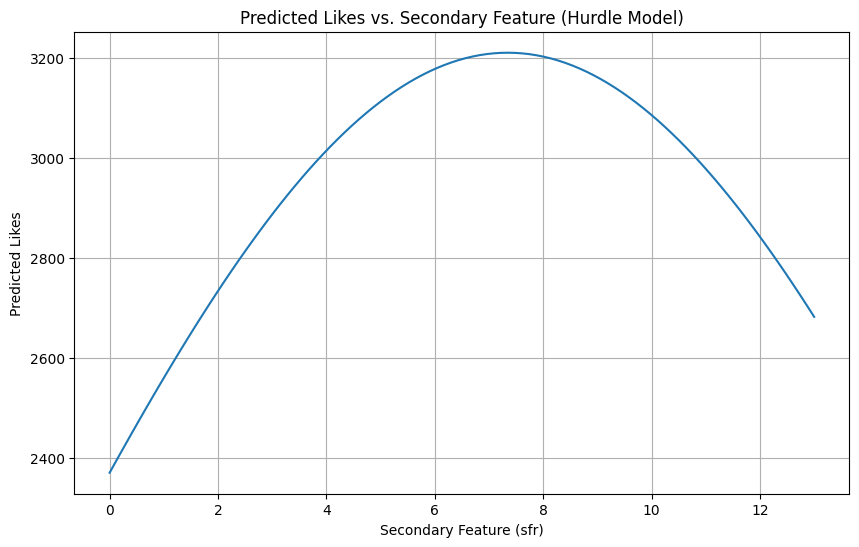

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-fit logit_result and nbreg_result to ensure they are consistent with
# the features intended for this prediction plot (i.e., including 'sfr').
# This is necessary because the global logit_result and nbreg_result variables
# might have been overwritten by models trained with different feature sets
# in subsequent cells.

# Define features for the logit and nbreg models that include 'sfr'
model_features_for_sfr_plot = ['time','log(wc)','saturation','post interval','revenue','posts','sfr','sfr2']

# --- Re-fit Logistic Regression (logit_result) ---
y_binary_sfr = (df1['likes'] > 0).astype(int) # ensure y_binary is up-to-date
X_logit_sfr = df1[model_features_for_sfr_plot]
X_logit_sfr['sfr2'] = X_logit_sfr['sfr'] ** 2 # Ensure sfr2 is calculated here
X_logit_sfr = sm.add_constant(X_logit_sfr)
# Ensure columns are numeric and handle NaNs
for col in X_logit_sfr.columns:
    X_logit_sfr[col] = pd.to_numeric(X_logit_sfr[col], errors='coerce')
X_logit_sfr = X_logit_sfr.fillna(X_logit_sfr.mean())
# Drop constant or near-constant columns if necessary (mimic previous logic)
constant_cols_logit_sfr = [col for col in X_logit_sfr.columns if col != 'const' and X_logit_sfr[col].nunique() <= 1]
if constant_cols_logit_sfr:
    X_logit_sfr = X_logit_sfr.drop(columns=constant_cols_logit_sfr)
# Re-fit the logit model
logit_model = sm.Logit(y_binary_sfr, X_logit_sfr)
logit_result = logit_model.fit_regularized(method='l1', alpha=0.1, disp=False)

# --- Re-fit Negative Binomial Regression (nbreg_result) ---
df_positive_likes_sfr = df1[df1['likes'] > 0]
y_positive_sfr = df_positive_likes_sfr['likes']
# Use the same feature set for X as logit_result, aligning indices
X_nbreg_sfr = df1[model_features_for_sfr_plot].loc[df_positive_likes_sfr.index]
X_nbreg_sfr['sfr2'] = X_nbreg_sfr['sfr'] ** 2 # Ensure sfr2 is calculated here
X_nbreg_sfr = sm.add_constant(X_nbreg_sfr)
# Ensure columns are numeric and handle NaNs
for col in X_nbreg_sfr.columns:
    X_nbreg_sfr[col] = pd.to_numeric(X_nbreg_sfr[col], errors='coerce')
X_nbreg_sfr = X_nbreg_sfr.fillna(X_nbreg_sfr.mean())
# Scale features for nbreg model, excluding 'const' for scaling
#X_nbreg_sfr_features = X_nbreg_sfr.drop(columns='const')
#scaler_nbreg_sfr = StandardScaler()
#X_nbreg_scaled_sfr_features = scaler_nbreg_sfr.fit_transform(X_nbreg_sfr_features)
#X_nbreg_scaled_sfr = pd.DataFrame(X_nbreg_scaled_sfr_features, columns=X_nbreg_sfr_features.columns, index=X_nbreg_sfr_features.index)
#X_nbreg_scaled_sfr = sm.add_constant(X_nbreg_scaled_sfr, has_constant='add')
# Re-fit the nbreg model
nbreg_model = sm.NegativeBinomial(y_positive_sfr, X_nbreg_sfr)
nbreg_result = nbreg_model.fit(disp=False) # disp=False to suppress iteration output

# --- Prediction Phase for Hurdle Model ---

# 1. Create a range of 'secondary feature' values for prediction
secondary_feature_range = np.linspace(df1['sfr'].min(), df1['sfr'].max(), 100)

# 2. Create a DataFrame for prediction, holding other variables constant
# We'll use the mean of other features from the original DataFrame X

# Re-extract features to ensure consistency with the last model run
# IMPORTANT: Align features_for_prediction with the features used for logit_result and nbreg_result
# The model was trained with 'sfr' and 'sfr2', so features_for_prediction must also include 'sfr2'
features_for_prediction = ['time','log(wc)','saturation','post interval','revenue','posts','sfr','sfr2'] # Corrected list to include 'sfr2'
X_original = df1[features_for_prediction]
X_original['sfr2'] = X_original['sfr'] ** 2 # Calculate sfr2 for X_original

# Add constant for statsmodels
X_original = sm.add_constant(X_original, has_constant='add')

# Ensure all columns are numeric and handle NaNs for mean calculation
for col in X_original.columns:
    X_original[col] = pd.to_numeric(X_original[col], errors='coerce')
X_original = X_original.fillna(X_original.mean())


# Create a template for new predictions with mean values for other features
pred_df = pd.DataFrame(columns=X_original.columns)
mean_values = X_original.mean().to_dict()

# Populate pred_df with mean values for all columns
for col in pred_df.columns:
    pred_df[col] = [mean_values[col]] * len(secondary_feature_range)

# Replace 'sfr' and 'sfr2' with the desired range and its square.
pred_df['sfr'] = secondary_feature_range
pred_df['sfr2'] = secondary_feature_range ** 2 # Calculate sfr2 based on the new range

# 3. Predict the probability of non-zero likes (from logit_result)
prob_non_zero = logit_result.predict(pred_df)

# 4. Predict the expected value of positive likes (from nbreg_result)
# Note: nbreg_result uses the same X as logit_result, which includes 'const'
expected_positive_likes = nbreg_result.predict(pred_df)
print(expected_positive_likes)
# 5. Combine predictions: P(likes > 0) * E(likes | likes > 0)
predicted_likes_hurdle = prob_non_zero * expected_positive_likes
# --- Visualization ---

plt.figure(figsize=(10, 6))
sns.lineplot(x=secondary_feature_range, y=predicted_likes_hurdle)
plt.title('Predicted Likes vs. Secondary Feature (Hurdle Model)')
plt.xlabel('Secondary Feature (sfr)') # Clarify the x-axis label
plt.ylabel('Predicted Likes')
plt.grid(True)
plt.show()

### Engagement Intensity per Day of the Week

/tmp/ipykernel_3093/1510249149.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='likes', data=avg_likes_per_day, palette='viridis')


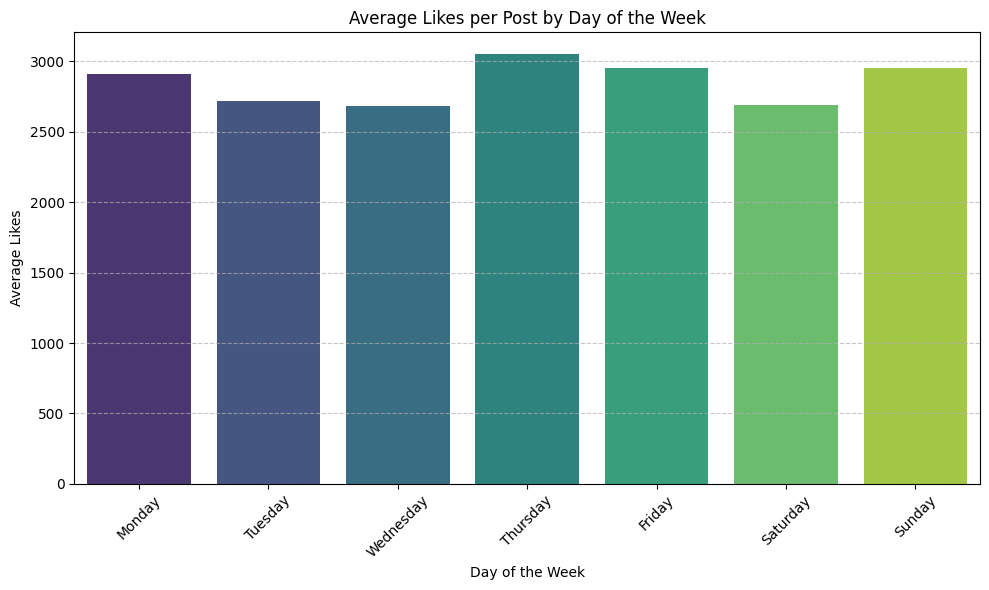

In [ ]:
# Ensure 'timestamp' is in datetime format
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

# Extract the day of the week (Monday=0, Sunday=6)
df1['day_of_week'] = df1['timestamp'].dt.dayofweek

# Group by day of the week and calculate the mean of 'likes'
avg_likes_per_day = df1.groupby('day_of_week')['likes'].mean().reset_index()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_likes_per_day['day_name'] = avg_likes_per_day['day_of_week'].map(lambda x: day_names[x])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='likes', data=avg_likes_per_day, palette='viridis')
plt.title('Average Likes per Post by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Likes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Engagement Intensity (Likes + Comments) per Day of the Week

/tmp/ipykernel_3093/1461654555.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='engagement_intensity', data=avg_engagement_per_day, palette='viridis')


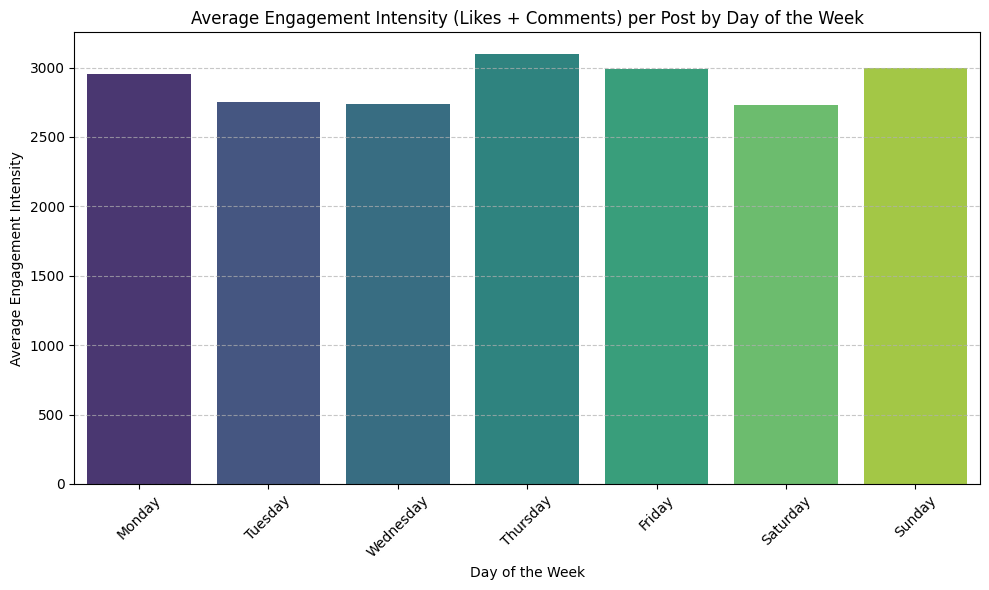

In [ ]:
# Calculate engagement intensity (likes + comments)
df1['engagement_intensity'] = df1['likes'] + df1['comments']

# Ensure 'timestamp' is in datetime format (if not already)
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

# Extract the day of the week (Monday=0, Sunday=6)
df1['day_of_week'] = df1['timestamp'].dt.dayofweek

# Group by day of the week and calculate the mean of 'engagement_intensity'
avg_engagement_per_day = df1.groupby('day_of_week')['engagement_intensity'].mean().reset_index()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_engagement_per_day['day_name'] = avg_engagement_per_day['day_of_week'].map(lambda x: day_names[x])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='engagement_intensity', data=avg_engagement_per_day, palette='viridis')
plt.title('Average Engagement Intensity (Likes + Comments) per Post by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Engagement Intensity')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

xk=scale_fac*(b+(beta*sk)+(zeta*sf)+(eta*sf2))